# EDA — Beach Volleyball (vb_matches.csv)

### BLOQUE 1: IMPORTACIÓN, ESTRUCTURA Y LIMPIEZA 

##### Importar librerías y cargar csv

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker


df = pd.read_csv(r"C:\Users\Admin\OneDrive - Universidad del Norte\Escritorio\dataviz_202630\python\vb_matches.csv")  # ajusta la ruta si tu archivo está en otra carpeta
df.head()

,circuit,tournament,country,year,date,gender,match_num,w_player1,w_p1_birthdate,w_p1_age,...,l_p1_tot_blocks,l_p1_tot_digs,l_p2_tot_attacks,l_p2_tot_kills,l_p2_tot_errors,l_p2_tot_hitpct,l_p2_tot_aces,l_p2_tot_serve_errors,l_p2_tot_blocks,l_p2_tot_digs
0,AVP,Huntington Beach,United States,2002,2002-05-24,M,1,Kevin Wong,1972-09-12,29.694730,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN
1,AVP,Huntington Beach,United States,2002,2002-05-24,M,2,Brad Torsone,1975-01-14,27.356605,...,2.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,AVP,Huntington Beach,United States,2002,2002-05-24,M,3,Eduardo Bacil,1971-03-11,31.203285,...,1.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,AVP,Huntington Beach,United States,2002,2002-05-24,M,4,Brent Doble,1970-01-03,32.386037,...,2.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,0.0,NaN
4,AVP,Huntington Beach,United States,2002,2002-05-24,M,5,Albert Hannemann,1970-05-04,32.054757,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN


##### Revisión de estructura

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76756 entries, 0 to 76755
Data columns (total 65 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   circuit                76756 non-null  object 
 1   tournament             76756 non-null  object 
 2   country                76756 non-null  object 
 3   year                   76756 non-null  int64  
 4   date                   76756 non-null  object 
 5   gender                 76756 non-null  object 
 6   match_num              76756 non-null  int64  
 7   w_player1              76756 non-null  object 
 8   w_p1_birthdate         76373 non-null  object 
 9   w_p1_age               76373 non-null  float64
 10  w_p1_hgt               72790 non-null  float64
 11  w_p1_country           76744 non-null  object 
 12  w_player2              76756 non-null  object 
 13  w_p2_birthdate         76348 non-null  object 
 14  w_p2_age               76348 non-null  float64
 15  w_

In [3]:
df.shape

(76756, 65)

In [4]:
df.columns

Index(['circuit', 'tournament', 'country', 'year', 'date', 'gender',
       'match_num', 'w_player1', 'w_p1_birthdate', 'w_p1_age', 'w_p1_hgt',
       'w_p1_country', 'w_player2', 'w_p2_birthdate', 'w_p2_age', 'w_p2_hgt',
       'w_p2_country', 'w_rank', 'l_player1', 'l_p1_birthdate', 'l_p1_age',
       'l_p1_hgt', 'l_p1_country', 'l_player2', 'l_p2_birthdate', 'l_p2_age',
       'l_p2_hgt', 'l_p2_country', 'l_rank', 'score', 'duration', 'bracket',
       'round', 'w_p1_tot_attacks', 'w_p1_tot_kills', 'w_p1_tot_errors',
       'w_p1_tot_hitpct', 'w_p1_tot_aces', 'w_p1_tot_serve_errors',
       'w_p1_tot_blocks', 'w_p1_tot_digs', 'w_p2_tot_attacks',
       'w_p2_tot_kills', 'w_p2_tot_errors', 'w_p2_tot_hitpct', 'w_p2_tot_aces',
       'w_p2_tot_serve_errors', 'w_p2_tot_blocks', 'w_p2_tot_digs',
       'l_p1_tot_attacks', 'l_p1_tot_kills', 'l_p1_tot_errors',
       'l_p1_tot_hitpct', 'l_p1_tot_aces', 'l_p1_tot_serve_errors',
       'l_p1_tot_blocks', 'l_p1_tot_digs', 'l_p2_tot_attacks',


(agregar observaciones)

##### Conversión de tipo de datos

Fechas

In [6]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['w_p1_birthdate'] = pd.to_datetime(df['w_p1_birthdate'], errors='coerce')
df['w_p2_birthdate'] = pd.to_datetime(df['w_p2_birthdate'], errors='coerce')
df['l_p1_birthdate'] = pd.to_datetime(df['l_p1_birthdate'], errors='coerce')
df['l_p2_birthdate'] = pd.to_datetime(df['l_p2_birthdate'], errors='coerce')

Categóricas

In [7]:
cols_categoricas = ['circuit', 'gender', 'bracket', 'round', 'country']
for col in cols_categoricas:
    df[col] = df[col].astype('category')

Revisión de duplicados

In [8]:
df.duplicated().sum()

0

Dividir **score** en sets

In [10]:
df['score'].str.split(',', expand=True).head()

,0,1,2
0,21-18,21-12,None
1,21-16,17-21,15-10
2,21-18,21-18,None
3,21-16,21-15,None
4,20-22,23-21,15-10


Limpiar **w_rank** y **l_rank**

In [40]:
df['w_rank_num'] = df['w_rank'].str.extract(r'^(\d+)')[0].astype(float)
df['l_rank_num'] = df['l_rank'].str.extract(r'^(\d+)')[0].astype(float)

#Visualizar sample del cambio
df[['w_rank', 'w_rank_num']].sample(10, random_state=1)

,w_rank,w_rank_num
48371,"28, Q1",28.0
76213,16,16.0
56386,18,18.0
31730,"17, Q1",17.0
53740,Q17,NaN
63219,19,19.0
8389,4,4.0
904,22,22.0
64560,15,15.0
62015,"14, Q1",14.0


#### Resumen del Bloque 1

- Dataset: 76.756 partidos, 65 variables
- Fechas convertidas: `date`, `w_p1_birthdate`, `w_p2_birthdate`, `l_p1_birthdate`, `l_p2_birthdate`
- Categóricas convertidas: `circuit`, `gender`, `bracket`, `round`, `country`
- Duplicados encontrados: 0
- Decisión de limpieza: no se eliminan filas por duplicados (no hay); las fechas quedan listas para el análisis temporal del Bloque 6

### BLOQUE 2: ANÁLISIS DE VALORES FALTANTES

% de NA por columna

In [12]:
na_pct = (df.isna().mean() * 100).sort_values(ascending=False)
na_pct

l_p1_tot_serve_errors    81.320027
w_p1_tot_serve_errors    81.318724
l_p2_tot_serve_errors    81.318724
w_p1_tot_errors          81.313513
w_p2_tot_errors          81.313513
                           ...    
w_player2                 0.000000
l_player1                 0.000000
l_player2                 0.000000
bracket                   0.000000
circuit                   0.000000
Length: 67, dtype: float64

Columnas con al menos un valor faltante

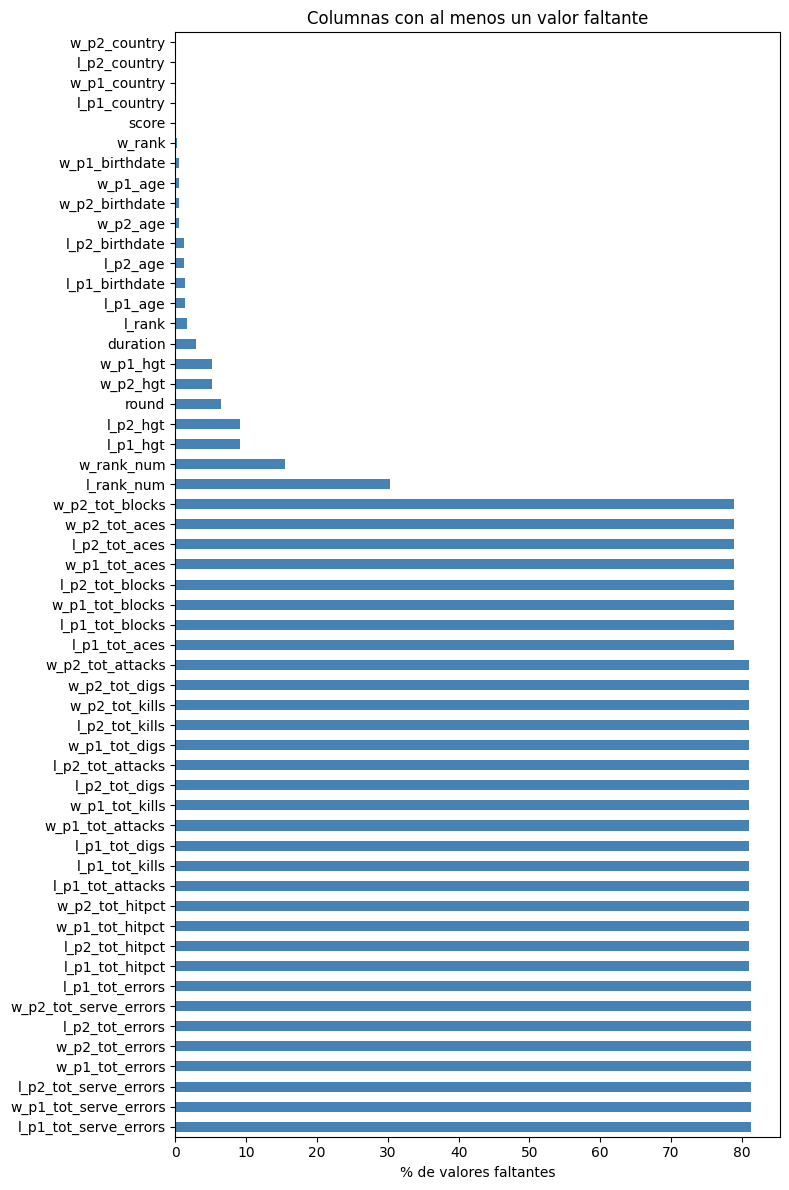

In [14]:
na_pct_con_nulos = na_pct[na_pct > 0]

plt.figure(figsize=(8, 12))
na_pct_con_nulos.plot(kind='barh', color='steelblue')
plt.xlabel('% de valores faltantes')
plt.title('Columnas con al menos un valor faltante')
plt.tight_layout()
plt.show()

In [15]:
na_stats_year = df.groupby(['year', 'circuit'], observed=True)['w_p1_tot_kills'].apply(lambda x: x.isna().mean() * 100)
na_stats_year = na_stats_year.reset_index(name='pct_na')
na_stats_year

,year,circuit,pct_na
0,2000,FIVB,100.000000
1,2001,FIVB,100.000000
2,2002,AVP,100.000000
3,2002,FIVB,100.000000
4,2003,AVP,88.702461
5,2003,FIVB,94.410480
6,2004,AVP,49.180328
7,2004,FIVB,95.907400
8,2005,AVP,45.804196
9,2005,FIVB,100.000000


c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed i

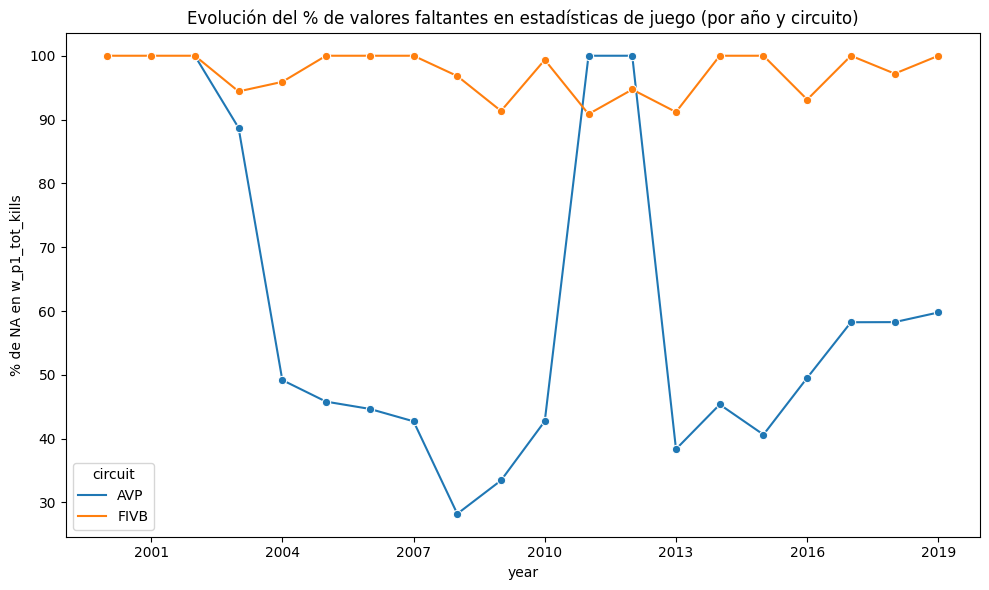

In [18]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=na_stats_year, x='year', y='pct_na', hue='circuit', marker='o')
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.ylabel('% de NA en w_p1_tot_kills')
plt.title('Evolución del % de valores faltantes en estadísticas de juego (por año y circuito)')
plt.tight_layout()
plt.show()

Revisión de NA en **rank**, **height** y **age**

In [41]:
cols_clave = ['w_rank_num', 'l_rank_num', 'w_p1_hgt', 'w_p2_hgt', 'l_p1_hgt', 'l_p2_hgt',
              'w_p1_age', 'w_p2_age', 'l_p1_age', 'l_p2_age']
df[cols_clave].isna().mean() * 100

w_rank_num    15.486737
l_rank_num    30.376778
w_p1_hgt       5.167023
w_p2_hgt       5.232164
l_p1_hgt       9.104174
l_p2_hgt       9.097660
w_p1_age       0.498984
w_p2_age       0.531555
l_p1_age       1.379697
l_p2_age       1.249414
dtype: float64

(agregar conclusiones)

### BLOQUE 3: VARIABLES CATEGÓRICAS

Frecuencias de **circuit**, **gender**, **bracket**, **round**

In [24]:
for col in ['circuit', 'gender', 'bracket', 'round']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True) * 100)
    print()

--- circuit ---
circuit
FIVB    51403
AVP     25353
Name: count, dtype: int64
circuit
FIVB    66.969357
AVP     33.030643
Name: proportion, dtype: float64

--- gender ---
gender
M    40270
W    36486
Name: count, dtype: int64
gender
M    52.464954
W    47.535046
Name: proportion, dtype: float64

--- bracket ---
bracket
Qualifier Bracket        22245
Winner's Bracket         20726
Contender's Bracket      11686
Pool A                    2212
Pool B                    2193
Pool C                    2139
Pool D                    2130
Semifinals                1950
Pool F                    1805
Pool E                    1803
Pool G                    1660
Pool H                    1659
Country Quota Matches     1241
Gold Medal                 651
Bronze Medal               649
Finals                     337
Pool L                     234
Pool J                     234
Pool K                     233
Pool M                     156
Pool N                     126
Pool O                     1

Gráfico de barras para **circuit**, y **gender**

c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed i

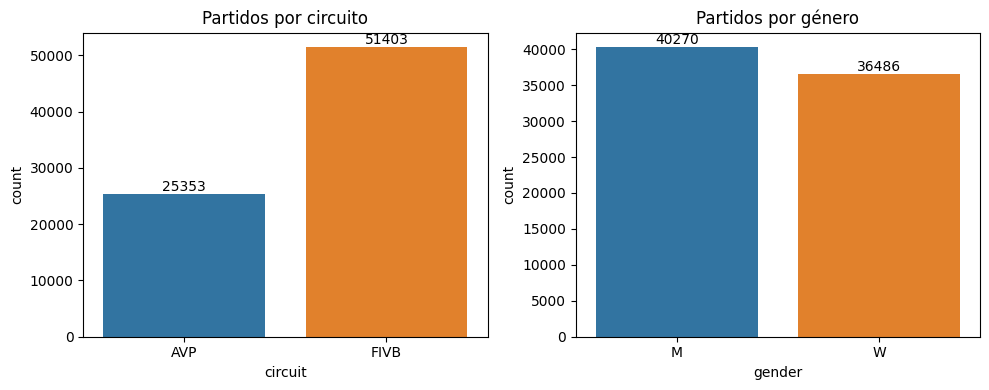

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(data=df, x='circuit', ax=axes[0])
axes[0].set_title('Partidos por circuito')
for contenedor in axes[0].containers:
    axes[0].bar_label(contenedor)

sns.countplot(data=df, x='gender', ax=axes[1])
axes[1].set_title('Partidos por género')
for contenedor in axes[1].containers:
    axes[1].bar_label(contenedor)

plt.tight_layout()
plt.show()

Gráfico de barras para **round**

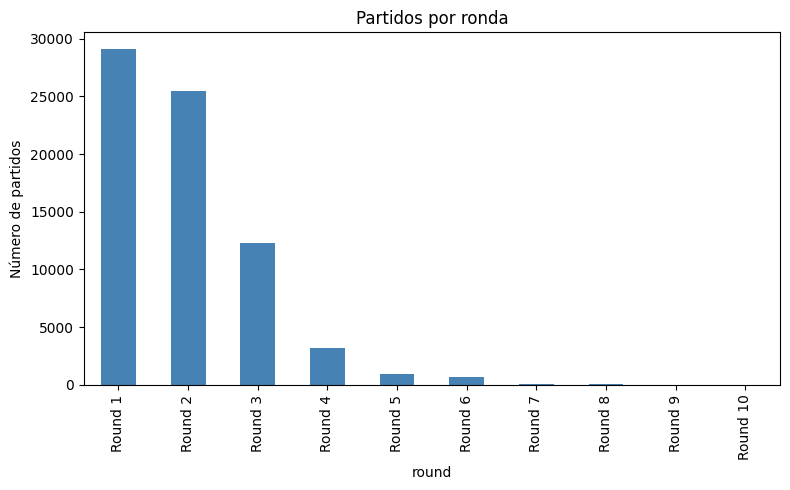

In [27]:
plt.figure(figsize=(8, 5))
df['round'].value_counts().plot(kind='bar', color='steelblue')
plt.ylabel('Número de partidos')
plt.title('Partidos por ronda')
plt.tight_layout()
plt.show()

Top países organizadores y top países de procedencia de jugadores

In [28]:
print("Top 10 países organizadores de torneos:")
print(df['country'].value_counts().head(10))
print()
print("Top 10 países de procedencia de jugadores (w_p1_country):")
print(df['w_p1_country'].value_counts().head(10))

Top 10 países organizadores de torneos:
country
United States    27311
China             6158
Switzerland       4116
Poland            3358
Russia            3318
Austria           3302
Norway            3280
France            2567
Germany           2297
Brazil            2070
Name: count, dtype: int64

Top 10 países de procedencia de jugadores (w_p1_country):
w_p1_country
United States    29394
Brazil            8277
Germany           4630
Switzerland       2456
Netherlands       2344
Canada            2179
Russia            2073
Austria           2015
China             2015
Italy             1918
Name: count, dtype: int64


Recategorización de **bracket**

In [29]:
mapa_bracket = {f'Pool {letra}': 'Pool play' for letra in 'ABCDEFGHIJKLMNOPQRSTUVWXY'}

mapa_bracket.update({
    "Contender's Bracket": 'Bracket eliminatorio',
    "Winner's Bracket": 'Bracket eliminatorio',
    'Qualifier Bracket': 'Bracket eliminatorio',
    'Qualifier Playoff': 'Bracket eliminatorio',
    'Lucky Losers': 'Bracket eliminatorio',
    'Country Quota Matches': 'Bracket eliminatorio',
    'Semifinals': 'Finales',
    'Finals': 'Finales',
    'Gold Medal': 'Finales',
    'Bronze Medal': 'Finales',
    '3rd Place': 'Finales',
})

df['bracket_grupo'] = df['bracket'].map(mapa_bracket)
df['bracket_grupo'].value_counts(dropna=False)

bracket_grupo
Bracket eliminatorio    56005
Pool play               17160
Finales                  3591
Name: count, dtype: int64

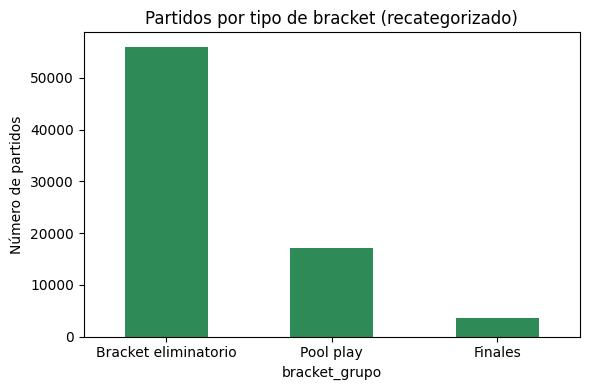

In [30]:
plt.figure(figsize=(6, 4))
df['bracket_grupo'].value_counts().plot(kind='bar', color='seagreen')
plt.ylabel('Número de partidos')
plt.title('Partidos por tipo de bracket (recategorizado)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### BLOQUE 4: OUTLIERS (VALORES ATÍPICOS)

Conversión de **duration** a minutos numéricos

In [31]:
df['duration_min'] = pd.to_timedelta(df['duration'], errors='coerce').dt.total_seconds() / 60
df['duration_min'].describe()

count    74507.000000
mean        43.922907
std         10.953282
min          2.000000
25%         36.000000
50%         42.000000
75%         51.000000
max        134.000000
Name: duration_min, dtype: float64

Combinar **age** and **height** de los 4 jugadores

In [34]:
age_cols = ['w_p1_age', 'w_p2_age', 'l_p1_age', 'l_p2_age']
hgt_cols = ['w_p1_hgt', 'w_p2_hgt', 'l_p1_hgt', 'l_p2_hgt']

edad_todos = pd.concat([df[c] for c in age_cols], ignore_index=True)
estatura_todos = pd.concat([df[c] for c in hgt_cols], ignore_index=True)

print(edad_todos.describe())
print(estatura_todos.describe())

count    304215.000000
mean         28.565364
std           5.075628
min          13.234771
25%          24.908966
50%          28.219028
75%          31.827515
max          67.764545
dtype: float64
count    285071.000000
mean         73.592554
std           3.652999
min          61.000000
25%          71.000000
50%          74.000000
75%          76.000000
max          85.000000
dtype: float64


Descripción de rango y duración

In [42]:
print(df['w_rank_num'].describe())
print(df['l_rank_num'].describe())
print(df['duration_min'].describe())

count    64869.000000
mean        13.406157
std          9.619255
min          1.000000
25%          5.000000
50%         12.000000
75%         21.000000
max         64.000000
Name: w_rank_num, dtype: float64
count    53440.000000
mean        16.812856
std          9.573560
min          1.000000
25%          9.000000
50%         16.000000
75%         24.000000
max         64.000000
Name: l_rank_num, dtype: float64
count    74507.000000
mean        43.922907
std         10.953282
min          2.000000
25%         36.000000
50%         42.000000
75%         51.000000
max        134.000000
Name: duration_min, dtype: float64


Boxplots

c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed i

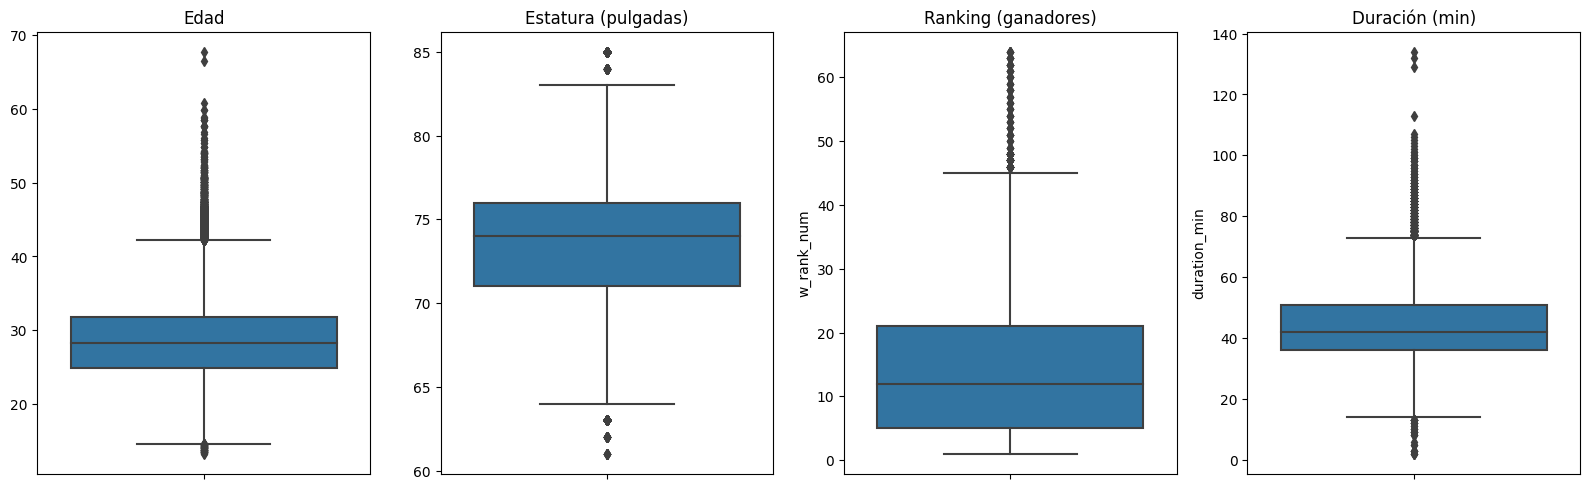

In [43]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

sns.boxplot(y=edad_todos, ax=axes[0])
axes[0].set_title('Edad')

sns.boxplot(y=estatura_todos, ax=axes[1])
axes[1].set_title('Estatura (pulgadas)')

sns.boxplot(y=df['w_rank_num'], ax=axes[2])
axes[2].set_title('Ranking (ganadores)')

sns.boxplot(y=df['duration_min'], ax=axes[3])
axes[3].set_title('Duración (min)')

plt.tight_layout()
plt.show()

Límites de outliers con el rango intercuartílico

In [44]:
q1 = edad_todos.quantile(0.25)
q3 = edad_todos.quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers_edad = edad_todos[(edad_todos < limite_inferior) | (edad_todos > limite_superior)]
print(f"Límites: [{limite_inferior:.1f}, {limite_superior:.1f}]")
print(f"Número de outliers en edad: {len(outliers_edad)} de {edad_todos.notna().sum()}")
outliers_edad.describe()

Límites: [14.5, 42.2]
Número de outliers en edad: 2668 de 304215


count    2668.000000
mean       44.024310
std         4.523718
min        13.234771
25%        42.787132
50%        43.727584
75%        45.338125
max        67.764545
dtype: float64

### BLOQUE 5: ANÁLISIS UNIVARIADO NUMÉRICO

Histogramas

c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be

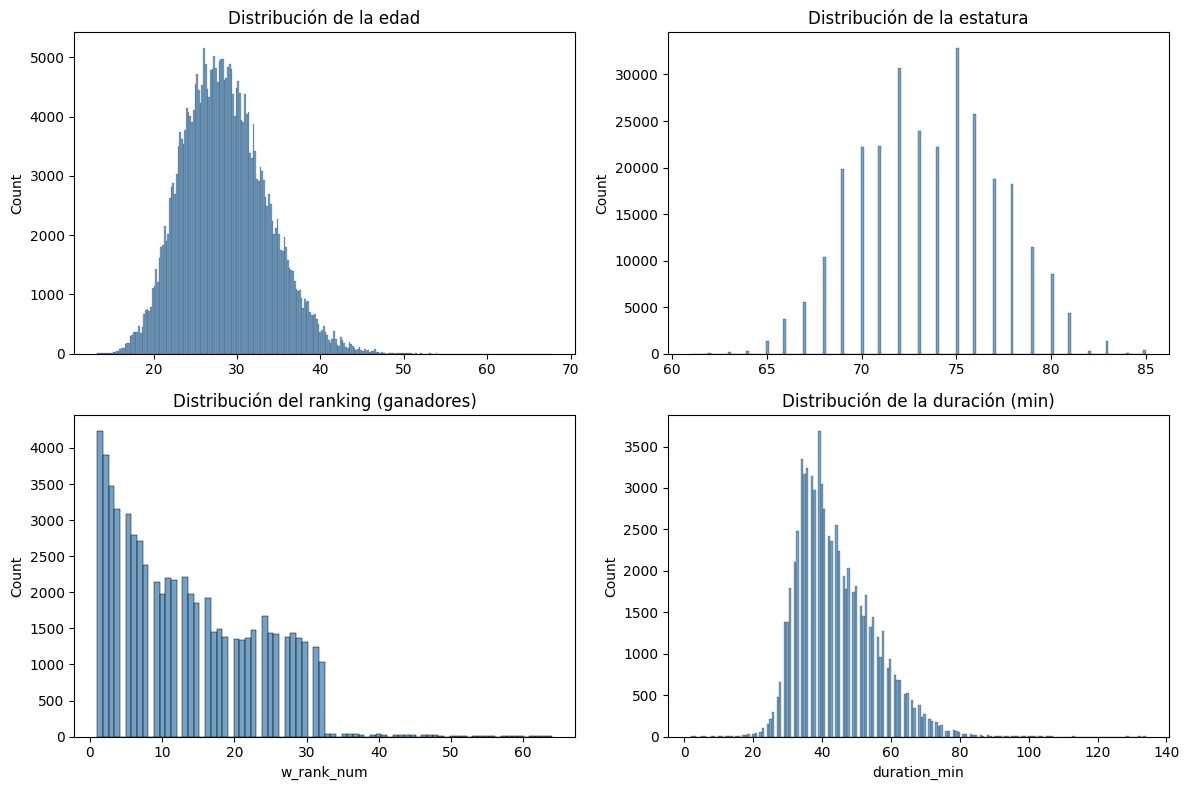

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(edad_todos, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribución de la edad')

sns.histplot(estatura_todos, ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Distribución de la estatura')

sns.histplot(df['w_rank_num'], ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Distribución del ranking (ganadores)')

sns.histplot(df['duration_min'], ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('Distribución de la duración (min)')

plt.tight_layout()
plt.show()

Densidad 

c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be

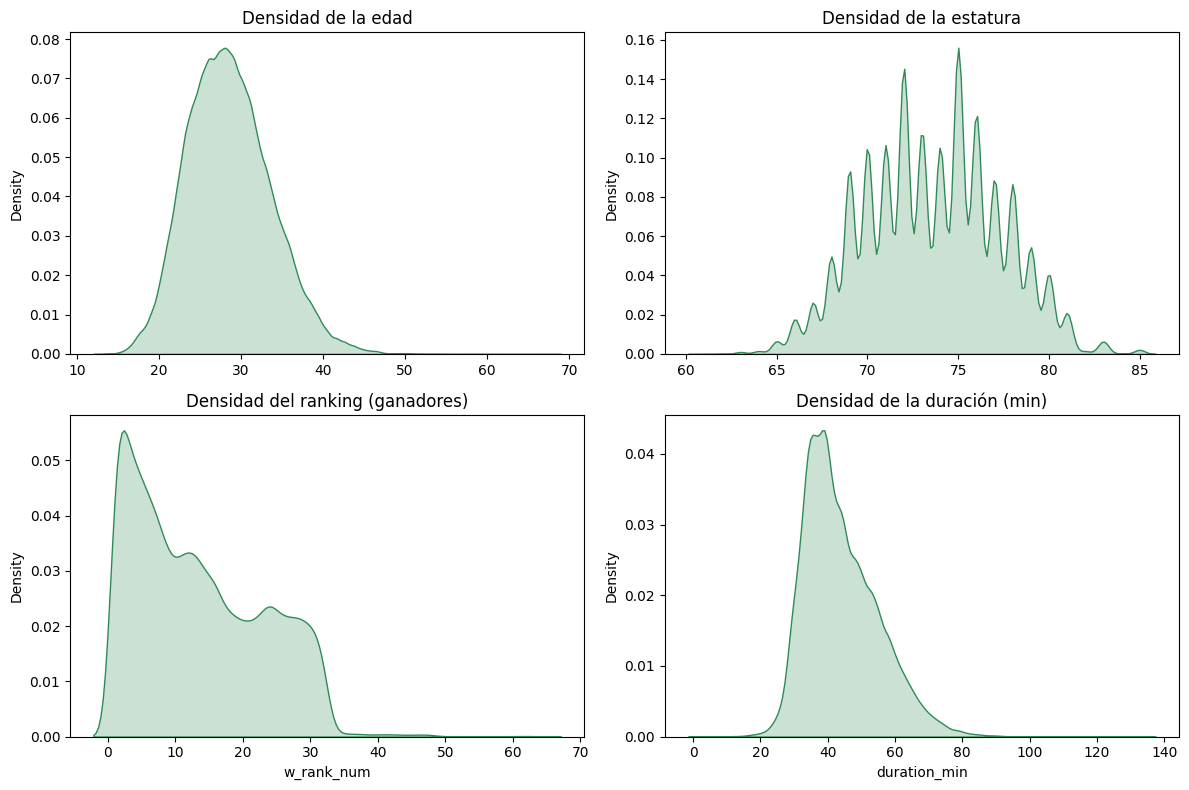

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.kdeplot(edad_todos, ax=axes[0, 0], fill=True, color='seagreen')
axes[0, 0].set_title('Densidad de la edad')

sns.kdeplot(estatura_todos, ax=axes[0, 1], fill=True, color='seagreen')
axes[0, 1].set_title('Densidad de la estatura')

sns.kdeplot(df['w_rank_num'], ax=axes[1, 0], fill=True, color='seagreen')
axes[1, 0].set_title('Densidad del ranking (ganadores)')

sns.kdeplot(df['duration_min'], ax=axes[1, 1], fill=True, color='seagreen')
axes[1, 1].set_title('Densidad de la duración (min)')

plt.tight_layout()
plt.show()

Tabla de estadísticos descriptivos

In [47]:
resumen_numerico = pd.DataFrame({
    'edad': edad_todos.describe(),
    'estatura': estatura_todos.describe(),
    'ranking_ganador': df['w_rank_num'].describe(),
    'duracion_min': df['duration_min'].describe(),
})
resumen_numerico

,edad,estatura,ranking_ganador,duracion_min
count,304215.000000,285071.000000,64869.000000,74507.000000
mean,28.565364,73.592554,13.406157,43.922907
std,5.075628,3.652999,9.619255,10.953282
min,13.234771,61.000000,1.000000,2.000000
25%,24.908966,71.000000,5.000000,36.000000
50%,28.219028,74.000000,12.000000,42.000000
75%,31.827515,76.000000,21.000000,51.000000
max,67.764545,85.000000,64.000000,134.000000


Asimetría y curtosis

In [48]:
asimetria_curtosis = pd.DataFrame({
    'variable': ['edad', 'estatura', 'ranking_ganador', 'duracion_min'],
    'skew': [edad_todos.skew(), estatura_todos.skew(), df['w_rank_num'].skew(), df['duration_min'].skew()],
    'kurt': [edad_todos.kurt(), estatura_todos.kurt(), df['w_rank_num'].kurt(), df['duration_min'].kurt()],
})
asimetria_curtosis

,variable,skew,kurt
0,edad,0.413226,0.223127
1,estatura,0.048660,-0.471456
2,ranking_ganador,0.587391,-0.365997
3,duracion_min,0.807100,0.815782


### BLOQUE 6: EVOLUCIÓN TEMPORAL 

Partidos por año y circuito

In [49]:
partidos_year_circuit = df.groupby(['year', 'circuit'], observed=True).size().reset_index(name='num_partidos')
partidos_year_circuit

,year,circuit,num_partidos
0,2000,FIVB,74
1,2001,FIVB,2424
2,2002,AVP,698
3,2002,FIVB,1881
4,2003,AVP,894
5,2003,FIVB,2290
6,2004,AVP,1891
7,2004,FIVB,2419
8,2005,AVP,2574
9,2005,FIVB,2661


c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed i

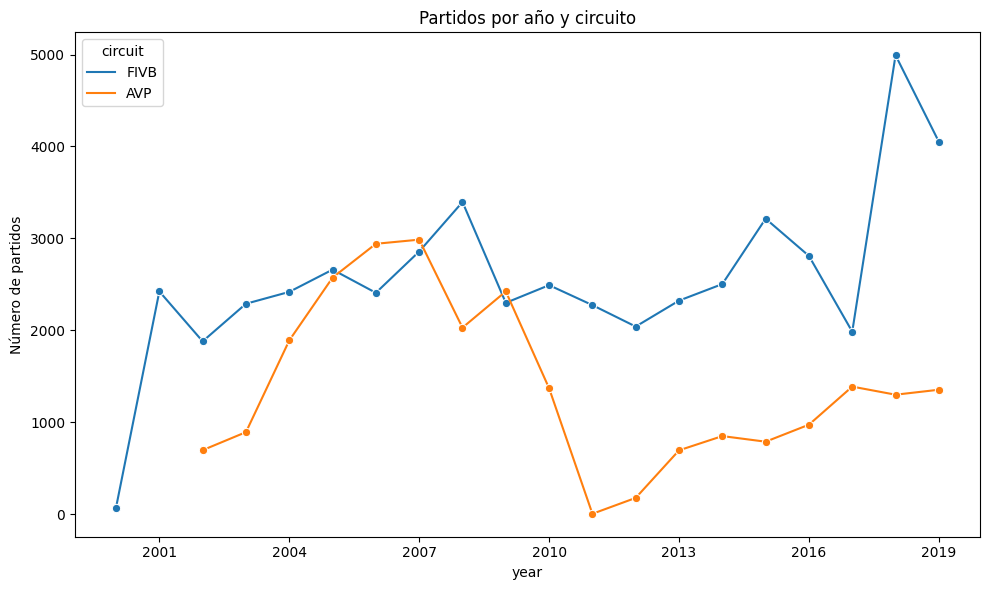

In [50]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=partidos_year_circuit, x='year', y='num_partidos', hue='circuit', marker='o')
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.ylabel('Número de partidos')
plt.title('Partidos por año y circuito')
plt.tight_layout()
plt.show()

Promedio de edad/estatura por partido y año

In [51]:
age_cols = ['w_p1_age', 'w_p2_age', 'l_p1_age', 'l_p2_age']
hgt_cols = ['w_p1_hgt', 'w_p2_hgt', 'l_p1_hgt', 'l_p2_hgt']

df['edad_promedio_partido'] = df[age_cols].mean(axis=1)
df['estatura_promedio_partido'] = df[hgt_cols].mean(axis=1)

edad_por_year = df.groupby('year')['edad_promedio_partido'].mean()
estatura_por_year = df.groupby('year')['estatura_promedio_partido'].mean()

edad_por_year

year
2000    29.449088
2001    27.857475
2002    28.714639
2003    28.972108
2004    29.247427
2005    29.060871
2006    29.065723
2007    29.138125
2008    29.177079
2009    29.126343
2010    28.827283
2011    28.187025
2012    28.633235
2013    27.842110
2014    28.071405
2015    28.559014
2016    28.592502
2017    28.341043
2018    27.128855
2019    27.727159
Name: edad_promedio_partido, dtype: float64

c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be

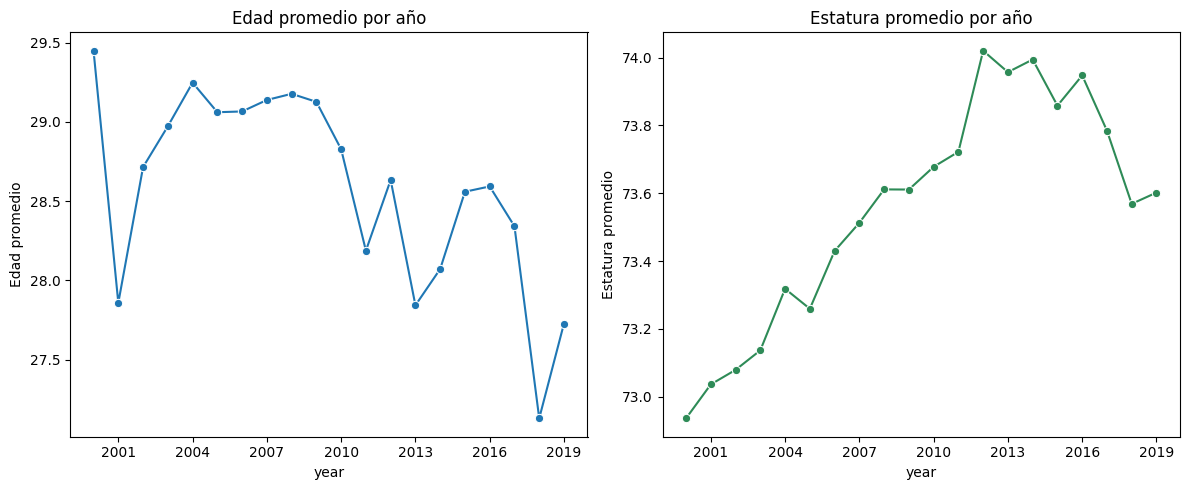

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(x=edad_por_year.index, y=edad_por_year.values, marker='o', ax=axes[0])
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[0].set_title('Edad promedio por año')
axes[0].set_xlabel('year')
axes[0].set_ylabel('Edad promedio')

sns.lineplot(x=estatura_por_year.index, y=estatura_por_year.values, marker='o', ax=axes[1], color='seagreen')
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1].set_title('Estatura promedio por año')
axes[1].set_xlabel('year')
axes[1].set_ylabel('Estatura promedio')

plt.tight_layout()
plt.show()

Comparación de FIVB vs AVP (partidos por año)

c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be

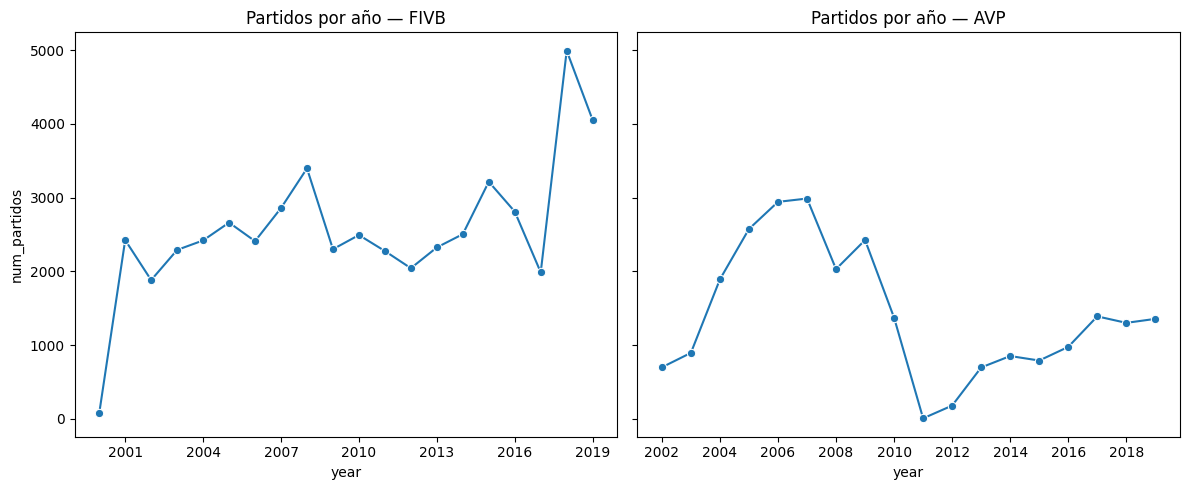

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, circ in zip(axes, ['FIVB', 'AVP']):
    datos_circ = partidos_year_circuit[partidos_year_circuit['circuit'] == circ]
    sns.lineplot(data=datos_circ, x='year', y='num_partidos', marker='o', ax=ax)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_title(f'Partidos por año — {circ}')

plt.tight_layout()
plt.show()

### BLOQUE 7: COMPARATIVO/BIVARIADO

Edad y estatura por género

c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed i

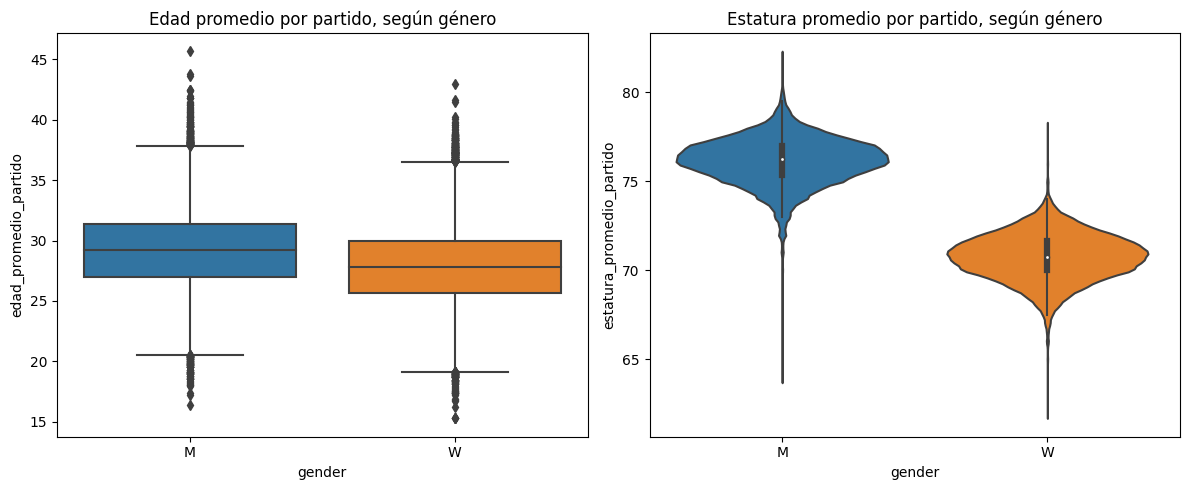

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='gender', y='edad_promedio_partido', data=df, ax=axes[0])
axes[0].set_title('Edad promedio por partido, según género')

sns.violinplot(x='gender', y='estatura_promedio_partido', data=df, ax=axes[1])
axes[1].set_title('Estatura promedio por partido, según género')

plt.tight_layout()
plt.show()

Edad por circuito

c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


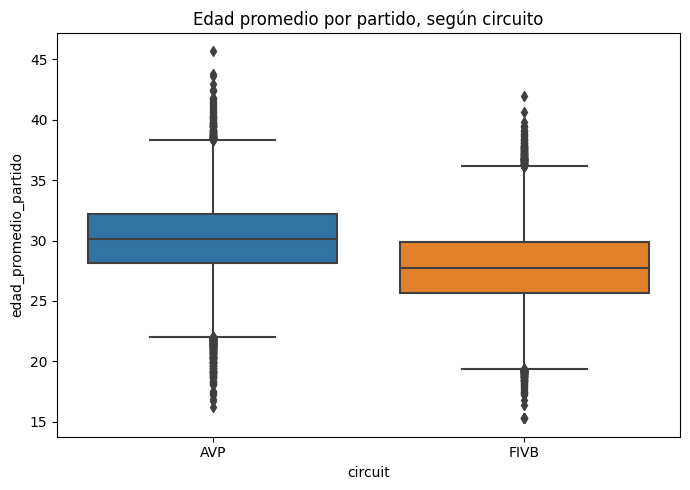

In [55]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='circuit', y='edad_promedio_partido', data=df)
plt.title('Edad promedio por partido, según circuito')
plt.tight_layout()
plt.show()

Creación de **rank_diff** y graficar

c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Admin\miniconda3\envs\dataviz2630_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be

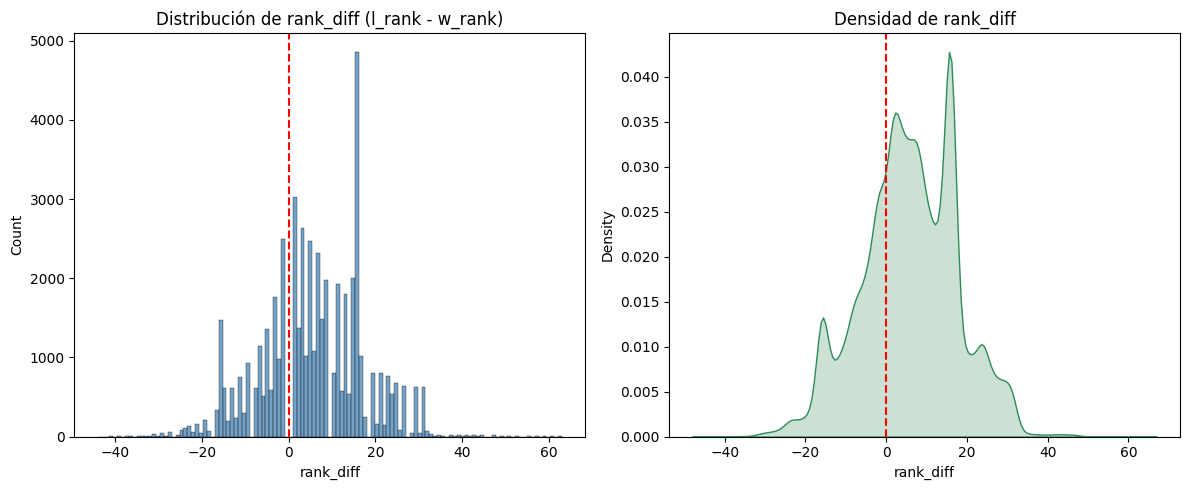

In [56]:
df['rank_diff'] = df['l_rank_num'] - df['w_rank_num']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['rank_diff'], ax=axes[0], color='steelblue')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Distribución de rank_diff (l_rank - w_rank)')

sns.kdeplot(df['rank_diff'], ax=axes[1], fill=True, color='seagreen')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Densidad de rank_diff')

plt.tight_layout()
plt.show()

Contar upsets

In [57]:
upsets = (df['rank_diff'] < 0).sum()
esperados = (df['rank_diff'] > 0).sum()
total_con_dato = df['rank_diff'].notna().sum()

print(f"Upsets: {upsets} ({upsets/total_con_dato*100:.1f}%)")
print(f"Resultado esperado: {esperados} ({esperados/total_con_dato*100:.1f}%)")

Upsets: 15967 (29.9%)
Resultado esperado: 37408 (70.1%)


Matriz de correlación 

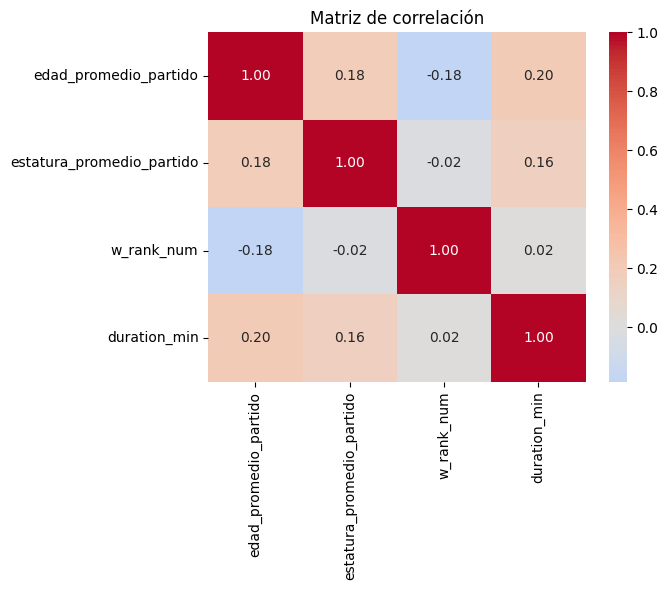

In [58]:
cols_correlacion = ['edad_promedio_partido', 'estatura_promedio_partido', 'w_rank_num', 'duration_min']
matriz_corr = df[cols_correlacion].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

### BLOQUE 8: ESTADÍSTICAS DE JUEGO Y SÍNTESIS FINAL